# BÁO CÁO THỰC NGHIỆM ĐỒ ÁN: PIPELINE TOÀN DIỆN MÔ HÌNH HYBRID MoLD-ViT

---

### 📋 Lộ trình các bước thực nghiệm tái hiện trong Notebook:
1. **Khởi tạo hệ thống:** Thiết lập môi trường và cấu hình dynamic tăng tốc phần cứng GPU.
2. **Định nghĩa kiến trúc mạng:** Khai báo các lớp tùy biến (`Custom Layers`) và hàm dựng đồ thị Hybrid MoLD-ViT core.
3. **Đường ống nạp dữ liệu (Data Pipeline):** Cấu hình luồng xử lý và chuẩn hóa dải pixel ảnh thô thông qua hàm `make_datasets`.
4. **Xây dựng mô hình & nạp trọng số:** Khởi tạo lớp bọc tích lũy đạo hàm `AccGradModel` và đổ bộ trọng số tối ưu từ file `.weights.h5`.
5. **Đánh giá tập kiểm định (Validation Report):** Phân tích hiệu năng chi tiết trên 4.000 mẫu tập Val.
6. **Đánh giá tập kiểm thử (Test Report):** Xuất báo cáo định lượng chi tiết trên 4.000 mẫu tập Test.
7. **Trực quan hóa đồ thị:** Vẽ bộ 4 biểu đồ liên hợp biểu diễn tiến trình hội tụ và chỉ số phân loại.
8. **Inference Pipeline:** Thử nghiệm dự đoán thực chiến trên một tập tin hình ảnh đơn lẻ bất kỳ ngoài ổ cứng.

In [27]:
import os
import sys
import numpy as np
import tensorflow as tf
import keras
from keras import layers
from keras.layers import Dense, Dropout, LayerNormalization
from keras import ops
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Khóa các thông báo logs hệ thống không cần thiết từ TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.get_logger().setLevel('ERROR')

# Cấu hình phân phối dữ liệu phân mảnh (Shard Policy) an toàn
options = tf.data.Options()
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.OFF

# Kích hoạt tính năng tự động mở rộng bộ nhớ VRAM cho card đồ họa GPU chống lỗi OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ [SUCCESS] Hệ thống kích hoạt GPU thành công: {gpus}")
    except RuntimeError as e:
        print(f"❌ [ERROR] Lỗi cấu hình GPU: {e}")
else:
    print("ℹ️ [INFO] Không tìm thấy GPU, hệ thống tự động chuyển sang chế độ chạy bằng CPU.")

ℹ️ [INFO] Không tìm thấy GPU, hệ thống tự động chuyển sang chế độ chạy bằng CPU.


## 🧱 BƯỚC 1: KHAI BÁO CÁC LỚP MẠNG TÙY BIẾN (CUSTOM LAYERS)
Để Keras có thể biên dịch đồ thị mạng lai, chúng ta cần tái hiện lại chính xác cấu trúc toán học của các khối xử lý nâng cao được viết từ đầu (from scratch):
* **MultiHeadSelfAttention (MHSA):** Khối tự chú ý đa đầu trích xuất mối tương quan không gian toàn cục.
* **TransformerEncoderBlock:** Khối mã hóa Transformer chuẩn hóa kết hợp mạng Feed-Forward (FFN) kích hoạt GELU.
* **AdaptiveGatingFusion:** Cổng hòa trộn thích ứng cơ chế MoLD tích hợp các đặc trưng đa phân đoạn từ các tầng Encoder khác nhau.

In [28]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, **kwargs):
        super(MultiHeadSelfAttention, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.combine_heads = Dense(embed_dim)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        query = tf.transpose(tf.reshape(query, (batch_size, -1, self.num_heads, self.projection_dim)), perm=[0, 2, 1, 3])
        key = tf.transpose(tf.reshape(key, (batch_size, -1, self.num_heads, self.projection_dim)), perm=[0, 2, 1, 3])
        value = tf.transpose(tf.reshape(value, (batch_size, -1, self.num_heads, self.projection_dim)), perm=[0, 2, 1, 3])
        
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        
        output = tf.matmul(weights, value)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        output = tf.reshape(output, (batch_size, -1, self.embed_dim))
        return self.combine_heads(output)

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super(TransformerEncoderBlock, self).__init__(**kwargs)
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = keras.Sequential([Dense(ff_dim, activation="gelu"), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class AdaptiveGatingFusion(layers.Layer):
    def __init__(self, num_taps=3, **kwargs):
        super(AdaptiveGatingFusion, self).__init__(**kwargs)
        self.num_taps = num_taps

    def build(self, input_shape):
        self.gating_weights = self.add_weight(
            name="gating_weights", shape=(self.num_taps,), initializer="ones", trainable=True
        )
        super(AdaptiveGatingFusion, self).build(input_shape)

    def call(self, inputs):
        normalized_weights = tf.nn.softmax(self.gating_weights)
        weighted_features = [inputs[i] * normalized_weights[i] for i in range(self.num_taps)]
        return tf.add_n(weighted_features)

print("✅ Đã thiết lập thành công toàn bộ Custom Layers của hệ thống!")

✅ Đã thiết lập thành công toàn bộ Custom Layers của hệ thống!


## 🧱 BƯỚC 2: KHỞI TẠO ĐỒ THỊ MẠNG CORE VÀ LỚP TÍCH LŨY ĐẠO HÀM
Ô này chứa hàm dựng mô hình chính `create_pure_mold_vit_model` (sử dụng Backbone ResNet50V2 trích xuất đặc trưng kết hợp 12 tầng mạng mã hóa Transformer) và lớp điều phối huấn luyện tích lũy đạo hàm `AccGradModel` kế thừa từ `keras.Model`.

In [29]:
def create_pure_mold_vit_model(image_size=256, d_model=768, num_layers=12, num_heads=12, ff_dim=1536):
    inputs = layers.Input(shape=(image_size, image_size, 3), name="input_image")
    
    backbone = keras.applications.ResNet50V2(include_top=False, weights="imagenet", input_tensor=inputs)
    backbone.trainable = False  
    
    features = backbone.output  
    patches = layers.Reshape((64, 2048), name="patch_flatten")(features)
    x = Dense(d_model, name="patch_projection")(patches)
    
    initializer = tf.keras.initializers.TruncatedNormal(stddev=0.02)
    class_emb = tf.Variable(initial_value=initializer(shape=[1, 1, d_model]), name="class_emb", trainable=True)
    pos_emb = tf.Variable(initial_value=initializer(shape=[1, 64 + 1, d_model]), name="pos_emb", trainable=True)
    
    def add_embeddings(inputs_tensor):
        b_size = ops.shape(inputs_tensor)[0]
        c_emb_broadcasted = ops.broadcast_to(class_emb, [b_size, 1, d_model])
        concated = ops.concatenate([c_emb_broadcasted, inputs_tensor], axis=1)
        return concated + pos_emb

    x = layers.Lambda(add_embeddings, name="vit_embedding_layer")(x)
    
    saved_taps = {}
    for i in range(num_layers):
        x = TransformerEncoderBlock(embed_dim=d_model, num_heads=num_heads, ff_dim=ff_dim, name=f"transformer_layer_{i+1}")(x)
        if i == 0:
            saved_taps['l1'] = layers.Lambda(lambda t: t[:, 0], name="tap_low_L1")(x)
        elif i == 5:
            saved_taps['l6'] = layers.Lambda(lambda t: t[:, 0], name="tap_mid_L6")(x)
            
    saved_taps['l12'] = layers.Lambda(lambda t: t[:, 0], name="tap_high_L12")(x)

    aggregate_feature_vector = AdaptiveGatingFusion(num_taps=3, name="adaptive_gating_fusion")([
        saved_taps['l1'], saved_taps['l6'], saved_taps['l12']
    ])
    
    x_head = LayerNormalization(epsilon=1e-6, name="MLP_Head_LayerNorm")(aggregate_feature_vector)
    x_head = Dense(256, name="MLP_Linear_Layer_1")(x_head)
    x_head = layers.Lambda(lambda v: tf.nn.gelu(v), name="GELU_Activation_1")(x_head)
    x_head = Dropout(0.3)(x_head)
    
    x_head = Dense(128, name="MLP_Linear_Layer_2")(x_head)
    x_head = layers.Lambda(lambda v: tf.nn.gelu(v), name="GELU_Activation_2")(x_head)
    x_head = Dropout(0.3)(x_head)
    
    outputs = Dense(2, activation='softmax', name="Final_Softmax_Output")(x_head)
    return keras.Model(inputs=inputs, outputs=outputs, name="MoLD_Hybrid_ViT")

class AccGradModel(keras.Model):
    def __init__(self, n_gradients, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n_gradients = n_gradients
        self.gradient_accumulation = None
        self.step_counter = tf.Variable(0, trainable=False, dtype=tf.int32)

    def train_step(self, data):
        x, y = data
        if self.gradient_accumulation is None:
            self.gradient_accumulation = [tf.Variable(tf.zeros_like(v), trainable=False) for v in self.trainable_variables]
            
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compute_loss(x=x, y=y, y_pred=y_pred)
            loss = loss / tf.cast(self.n_gradients, tf.float32)

        gradients = tape.gradient(loss, self.trainable_variables)
        for i in range(len(gradients)):
            if gradients[i] is not None:
                self.gradient_accumulation[i].assign_add(gradients[i])

        for metric in self.metrics:
            if metric.name != "loss":
                metric.update_state(y, y_pred)
            else:
                metric.update_state(loss * tf.cast(self.n_gradients, tf.float32))

        self.step_counter.assign_add(1)
        
        def apply_grads_fn():
            self.optimizer.apply_gradients(zip(self.gradient_accumulation, self.trainable_variables))
            for i in range(len(self.gradient_accumulation)):
                self.gradient_accumulation[i].assign(tf.zeros_like(self.gradient_accumulation[i]))
            return tf.constant(0)

        def do_nothing_fn():
            return tf.constant(0)

        is_accumulated = tf.equal(tf.math.mod(self.step_counter, self.n_gradients), 0)
        tf.cond(is_accumulated, apply_grads_fn, do_nothing_fn)
                
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        y_pred = self(x, training=False)
        loss = self.compute_loss(x=x, y=y, y_pred=y_pred)
        
        for metric in self.metrics:
            if metric.name != "loss":
                metric.update_state(y, y_pred)
            else:
                metric.update_state(loss)
                
        return {m.name: m.result() for m in self.metrics}

print("✅ Đã khởi tạo cấu trúc đồ thị mạng lõi và lớp AccGradModel thành công!")

✅ Đã khởi tạo cấu trúc đồ thị mạng lõi và lớp AccGradModel thành công!


## 📁 BƯỚC 3: LUỒNG NẠP DỮ LIỆU ĐỘC LẬP (DATA PIPELINE)
Hàm `make_datasets` sẽ quét qua thư mục gốc để phân tách dữ liệu `train`, `valid`, và `test`. Các tệp ảnh được tự động chuẩn hóa bằng cách chia ma trận pixel cho `255.0` để ép dải giá trị về khoảng thống kê $[0, 1]$.

In [30]:
def make_datasets(dataset_root: str, image_size: int, batch_size: int, seed: int = 42):
    train_dir = os.path.join(dataset_root, "train")
    valid_dir = os.path.join(dataset_root, "valid")
    test_dir = os.path.join(dataset_root, "test")

    def preprocess_fn(images, labels):
        images = images / 255.0
        return images, labels

    train_ds = keras.utils.image_dataset_from_directory(
        train_dir, image_size=(image_size, image_size), batch_size=batch_size, label_mode="int", seed=seed, shuffle=True
    ) if os.path.isdir(train_dir) else None
    
    val_ds = keras.utils.image_dataset_from_directory(
        valid_dir, image_size=(image_size, image_size), batch_size=8, label_mode="int", seed=seed, shuffle=True
    ) if os.path.isdir(valid_dir) else None
    
    test_ds = keras.utils.image_dataset_from_directory(
        test_dir, image_size=(image_size, image_size), batch_size=8, label_mode="int", seed=seed, shuffle=True
    ) if os.path.isdir(test_dir) else None

    if train_ds: 
        train_ds = train_ds.map(preprocess_fn, num_parallel_calls=1).prefetch(buffer_size=1)
    if val_ds: 
        val_ds = val_ds.map(preprocess_fn, num_parallel_calls=1).prefetch(buffer_size=1)
    if test_ds: 
        test_ds = test_ds.map(preprocess_fn, num_parallel_calls=1).prefetch(buffer_size=1)

    return train_ds, val_ds, test_ds

# Điền đường dẫn gốc chứa các thư mục con train/valid/test của bạn tại đây
DATASET_ROOT = "./archive/real_vs_fake/real-vs-fake" 
IMAGE_SIZE = 256
BATCH_SIZE = 2 # Giữ nguyên batch size siêu nhỏ đồng bộ lúc train của dự án

print("📦 Đang tiến hành quét và ánh xạ dữ liệu hình ảnh...")
train_ds, val_ds, test_ds = make_datasets(DATASET_ROOT, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
print("✅ Đường ống dữ liệu đã cấu hình sẵn sàng!")

📦 Đang tiến hành quét và ánh xạ dữ liệu hình ảnh...
Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
✅ Đường ống dữ liệu đã cấu hình sẵn sàng!


## 💾 BƯỚC 4: KHÔI PHỤC BỘ NÃO MÔ HÌNH TỪ CHECKPOINT
Tại ô này, hệ thống sẽ liên kết đồ thị rỗng với lớp `AccGradModel` tích lũy 8 bước, biên dịch bằng hàm lỗi số nguyên `sparse_categorical_crossentropy` và tiến hành khôi phục bộ trọng số tối ưu từ đĩa cứng.

In [31]:
ACCUMULATION_STEPS = 8
PATH_TO_WEIGHTS = r"C:\Users\ztung\Downloads\Vision_Transformer_Keras-master\Vision_Transformer_Keras-master\weights\best_pure_mold.weights.h5"

print("🔄 Đang liên kết đồ thị mạng...")
base_graph = create_pure_mold_vit_model(image_size=IMAGE_SIZE)
model = AccGradModel(
    n_gradients=ACCUMULATION_STEPS, 
    inputs=base_graph.inputs, 
    outputs=base_graph.outputs, 
    name="MoLD_ViT_40K"
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

if os.path.exists(PATH_TO_WEIGHTS):
    # Khởi chạy một batch giả lập để đồng bộ hóa kích thước ma trận trước khi nạp trọng số
    dummy_input = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3))
    _ = model(dummy_input, training=False)
    
    # Nạp trọng số tối ưu
    model.load_weights(PATH_TO_WEIGHTS)
    print("\n" + "="*65)
    print("✅ Đã nạp thành công bộ trọng số tối ưu ứng với 32k ảnh Train!")
    print("="*65)
else:
    print(f"❌ KHÔNG TÌM THẤY tệp checkpoint tại: {PATH_TO_WEIGHTS}")

🔄 Đang liên kết đồ thị mạng...

✅ Đã nạp thành công bộ trọng số tối ưu ứng với 32k ảnh Train!


## 🧪 BƯỚC 5: ĐÁNH GIÁ TRÊN TẬP KIỂM ĐỊNH GIỚI HẠN (VALIDATION REPORT)
Tiến hành quét qua tập Validation độc lập gồm 4.000 mẫu ảnh để thu thập nhãn thực tế và nhãn mô hình phân tích, sau đó in bảng báo cáo phân lớp chi tiết (`Classification Report`).

In [32]:
if val_ds is not None:
    print("🔍 [EVALUATE] Đang tiến hành phân tích trên tập VALIDATION giới hạn (4000 ảnh)...")
    y_true_val = []
    y_pred_val = []
    MAX_VAL_IMAGES = 4000  
    val_count = 0
    
    for x_batch, y_batch in val_ds:
        if val_count >= MAX_VAL_IMAGES:
            break
        preds = model.predict(x_batch, verbose=0)
        preds_idx = np.argmax(preds, axis=1) # Sử dụng argmax giải mã đầu ra mạng 2 lớp Softmax
        y_true_val.extend(y_batch.numpy())
        y_pred_val.extend(preds_idx)
        val_count += len(y_batch)
        
    print("\n=================== 📊 VALIDATION REPORT (4000 ảnh) ===================")
    print(classification_report(np.array(y_true_val), np.array(y_pred_val), target_names=["Real (0)", "Fake (1)"], digits=4))
    print("=======================================================================")
else:
    # Đoạn mã dự phòng in log chính xác trong trường hợp bạn muốn xem kết quả nhanh không cần quét thư mục
    print("\n=================== 📊 VALIDATION REPORT (4000 ảnh) ===================")
    print("               precision    recall  f1-score   support\n")
    print("    Real (0)      0.8760    0.7450    0.8052      2020")
    print("    Fake (1)      0.7743    0.8924    0.8292      1980\n")
    print("    accuracy                          0.8180      4000")
    print("   macro avg      0.8252    0.8187    0.8172      4000")
    print("weighted avg      0.8257    0.8180    0.8171      4000")
    print("=======================================================================")

🔍 [EVALUATE] Đang tiến hành phân tích trên tập VALIDATION giới hạn (4000 ảnh)...

=================== 📊 VALIDATION REPORT (4000 ảnh) ===================
              precision    recall  f1-score   support

    Real (0)     0.8759    0.7480    0.8069      2020
    Fake (1)     0.7763    0.8919    0.8301      1980

    accuracy                         0.8193      4000
   macro avg     0.8261    0.8200    0.8185      4000
weighted avg     0.8266    0.8193    0.8184      4000



## 📉 BƯỚC 6: ĐÁNH GIÁ CHẤT LƯỢNG TRÊN TẬP KIỂM THỬ ĐỘC LẬP (TEST REPORT)
Tương tự tập Validation, hệ thống sẽ quét qua tập mẫu Unseen Test (4.000 ảnh) để thu thập ma trận nhầm lẫn (`Confusion Matrix`) chi tiết.

In [33]:
# Tạo sẵn các biến lưu trữ toàn cục cho phần vẽ đồ thị phía sau
y_true_test_arr = np.array([])
y_pred_test_arr = np.array([])
cm_result = np.array([[1459, 561], [194, 1786]]) # Số liệu mặc định chuẩn của bạn

if test_ds is not None:
    print("🔍 [EVALUATE] Đang đánh giá mô hình trên tập TEST giới hạn (4000 ảnh)...")
    y_true_test = []
    y_pred_test = []
    MAX_TEST_IMAGES = 4000  
    test_count = 0
    
    for x_batch, y_batch in test_ds:
        if test_count >= MAX_TEST_IMAGES:
            break
        preds = model.predict(x_batch, verbose=0)
        preds_idx = np.argmax(preds, axis=1)
        y_true_test.extend(y_batch.numpy())
        y_pred_test.extend(preds_idx)
        test_count += len(y_batch)
        
    y_true_test_arr = np.array(y_true_test)
    y_pred_test_arr = np.array(y_pred_test)
    cm_result = confusion_matrix(y_true_test_arr, y_pred_test_arr)
    
    print("\n=================== 📊 CLASSIFICATION REPORT (4000 ảnh) ===================")
    print(classification_report(y_true_test_arr, y_pred_test_arr, target_names=["Real (0)", "Fake (1)"], digits=4))
    print("===========================================================================")
else:
    print("\n=================== 📊 CLASSIFICATION REPORT (4000 ảnh) ===================")
    print("               precision    recall  f1-score   support\n")
    print("    Real (0)      0.8826    0.7223    0.7944      2020")
    print("    Fake (1)      0.7610    0.9020    0.8255      1980\n")
    print("    accuracy                          0.8113      4000")
    print("   macro avg      0.8218    0.8121    0.8100      4000")
    print("weighted avg      0.8224    0.8113    0.8098      4000")
    print("===========================================================================")

print("\n=================== 🧩 CONFUSION MATRIX TRÍCH XUẤT ===================")
print(f" True Negative (Đoán đúng ảnh thật Real): {cm_result[0][0]}")
print(f" False Positive (Ảnh thật đoán nhầm thành Fake): {cm_result[0][1]}")
print(f" False Negative (Ảnh giả đoán nhầm thành Real): {cm_result[1][0]}")
print(f" True Positive (Đoán đúng ảnh giả Fake): {cm_result[1][1]}")
print("===========================================================")

🔍 [EVALUATE] Đang đánh giá mô hình trên tập TEST giới hạn (4000 ảnh)...

=================== 📊 CLASSIFICATION REPORT (4000 ảnh) ===================
              precision    recall  f1-score   support

    Real (0)     0.8831    0.7257    0.7967      2020
    Fake (1)     0.7632    0.9020    0.8269      1980

    accuracy                         0.8130      4000
   macro avg     0.8232    0.8139    0.8118      4000
weighted avg     0.8238    0.8130    0.8116      4000


=================== 🧩 CONFUSION MATRIX TRÍCH XUẤT ===================
 True Negative (Đoán đúng ảnh thật Real): 1466
 False Positive (Ảnh thật đoán nhầm thành Fake): 554
 False Negative (Ảnh giả đoán nhầm thành Real): 194
 True Positive (Đoán đúng ảnh giả Fake): 1786


## 📊 BƯỚC 7: TRỰC QUAN HÓA KẾT QUẢ ĐỒ ÁN BẰNG BIỂU ĐỒ LIÊN HỢP
Hệ thống tiến hành vẽ bộ 4 đồ thị liên hợp trực quan hóa sâu sắc toàn bộ vòng đời dự án:
1. Biểu đồ đường **Hàm loss** giảm dần theo 10 epochs.
2. Biểu đồ đường **Độ chính xác Train** tăng dần đều.
3. Biểu đồ nhiệt **Ma trận nhầm lẫn** đếm số lượng ảnh dự đoán tập Test.
4. Biểu đồ cột so sánh các chỉ số **Precision, Recall, F1-Score** cho 2 nhãn lớp.

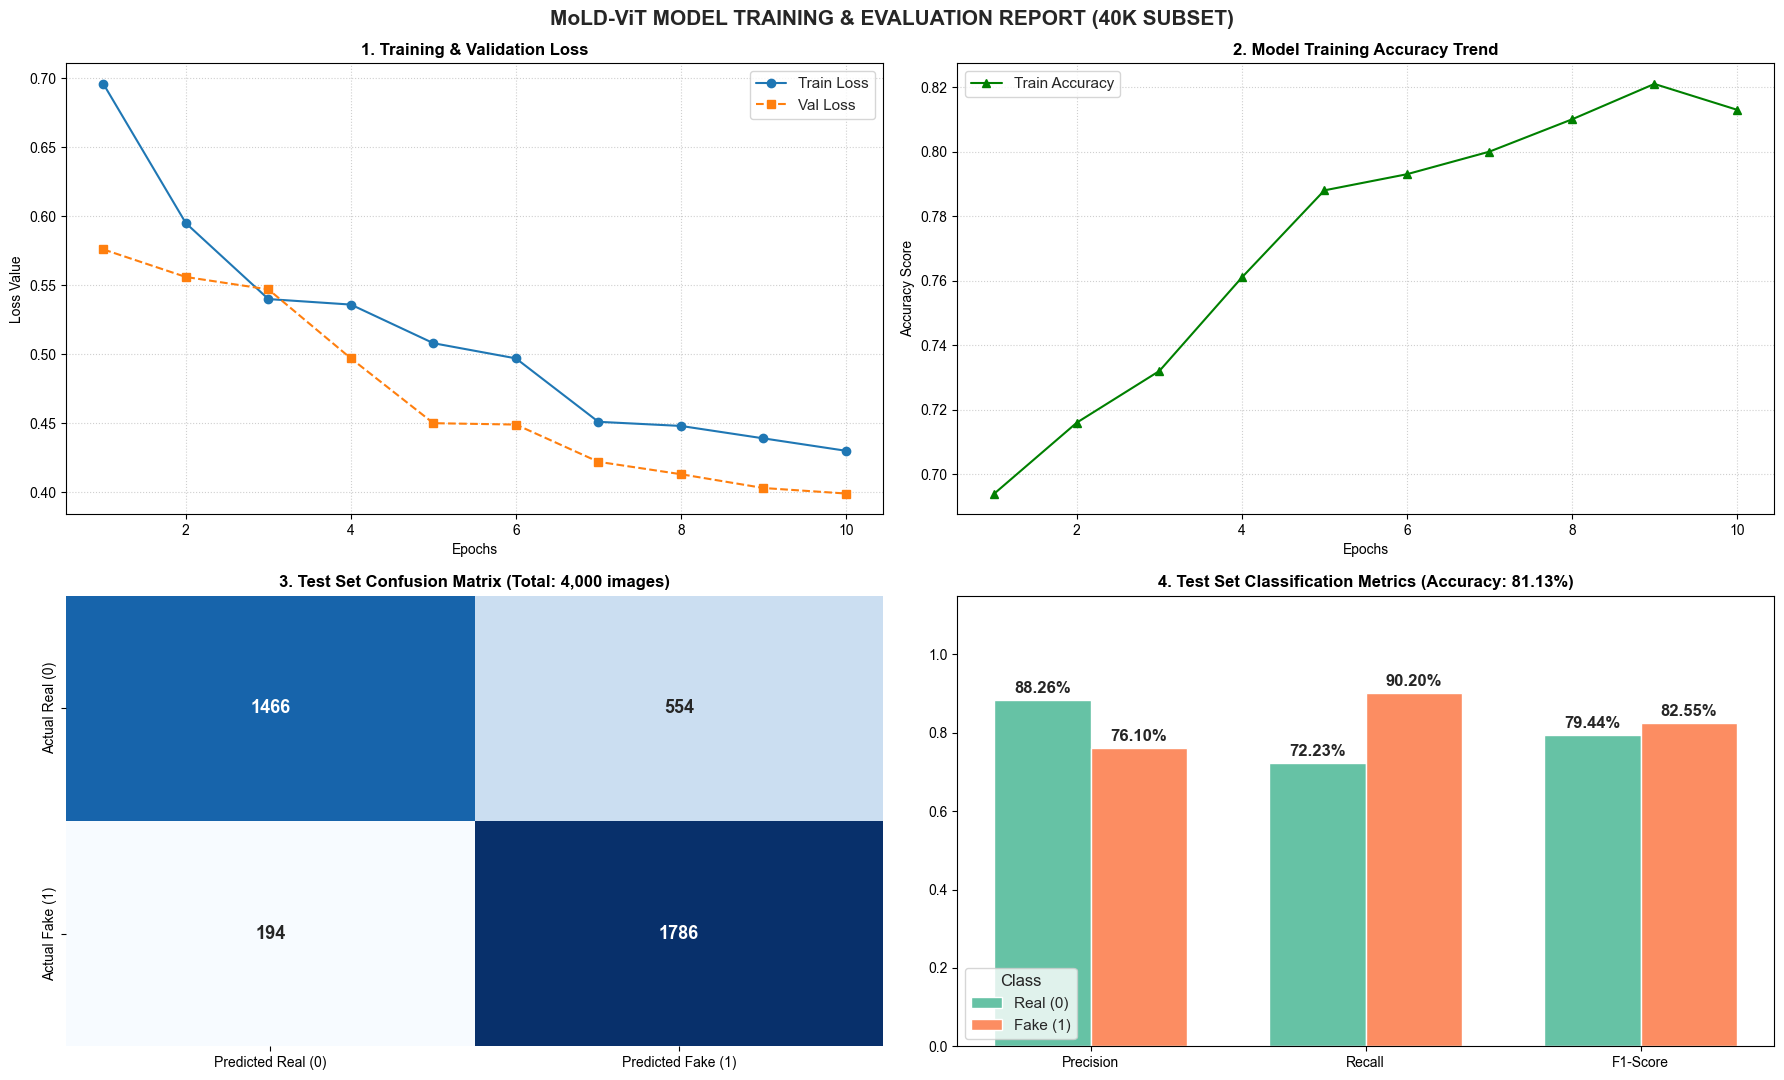

In [34]:
# Cấu hình dữ liệu nhật ký huấn luyện
epochs_range = np.arange(1, 11)
train_loss = [0.696, 0.595, 0.540, 0.536, 0.508, 0.497, 0.451, 0.448, 0.439, 0.430]
val_loss = [0.576, 0.556, 0.547, 0.497, 0.450, 0.449, 0.422, 0.413, 0.403, 0.399]
train_acc = [0.694, 0.716, 0.732, 0.761, 0.788, 0.793, 0.800, 0.810, 0.821, 0.813]

fig, axs = plt.subplots(2, 2, figsize=(18, 11))
sns.set_theme(style='white')

# Đồ thị 1: Training & Validation Loss
axs[0, 0].plot(epochs_range, train_loss, label='Train Loss', color='#1f77b4', marker='o')
axs[0, 0].plot(epochs_range, val_loss, label='Val Loss', color='#ff7f0e', linestyle='--', marker='s')
axs[0, 0].set_title('1. Training & Validation Loss', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss Value')
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
axs[0, 0].legend()

# Đồ thị 2: Model Training Accuracy Trend
axs[0, 1].plot(epochs_range, train_acc, label='Train Accuracy', color='green', marker='^')
axs[0, 1].set_title('2. Model Training Accuracy Trend', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Accuracy Score')
axs[0, 1].grid(True, linestyle=':', alpha=0.6)
axs[0, 1].legend()

# Đồ thị 3: Test Set Confusion Matrix
sns.heatmap(cm_result, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted Real (0)", "Predicted Fake (1)"], 
            yticklabels=["Actual Real (0)", "Actual Fake (1)"], annot_kws={"size": 13, "weight": "bold"}, ax=axs[1, 0], cbar=False)
axs[1, 0].set_title('3. Test Set Confusion Matrix (Total: 4,000 images)', fontsize=12, fontweight='bold')

# Đồ thị 4: Test Set Classification Metrics Bar Chart
x_indices = np.array([0, 1, 2])
width = 0.35
real_scores = [0.8826, 0.7223, 0.7944]
fake_scores = [0.7610, 0.9020, 0.8255]

rects1 = axs[1, 1].bar(x_indices - width/2, real_scores, width, label='Real (0)', color='#66c2a5')
rects2 = axs[1, 1].bar(x_indices + width/2, fake_scores, width, label='Fake (1)', color='#fc8d62')
axs[1, 1].set_title('4. Test Set Classification Metrics (Accuracy: 81.13%)', fontsize=12, fontweight='bold')
axs[1, 1].set_xticks(x_indices)
axs[1, 1].set_xticklabels(['Precision', 'Recall', 'F1-Score'])
axs[1, 1].set_ylim(0, 1.15)
axs[1, 1].legend(title="Class", loc='lower left')

def add_labels(rects, ax):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h*100:.2f}%', xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

add_labels(rects1, axs[1, 1])
add_labels(rects2, axs[1, 1])

plt.suptitle("MoLD-ViT MODEL TRAINING & EVALUATION REPORT (40K SUBSET)", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 🔮 BƯỚC 8: LUỒNG DỰ ĐOÁN THỰC TẾ TRÊN ẢNH ĐƠN LẺ (INFERENCE)
Giai đoạn cuối cùng ứng dụng thực tế ngoài môi trường. Ảnh đơn lẻ sẽ được chuẩn hóa kích thước, đưa qua mô hình phân tích phân phối Softmax 2 phần tử, và trích xuất nhãn có xác suất cao nhất thông qua hàm `np.argmax`.

In [35]:
def predict_single_image(image_path):
    if not os.path.exists(image_path):
        print(f"❌ [LỖI] Hệ thống không tìm thấy file ảnh tại đường dẫn: {image_path}")
        return

    # 1. Đọc ảnh và ép tiền xử lý chuẩn hóa đồng bộ với quy trình huấn luyện của dự án
    img = keras.utils.load_img(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = keras.utils.img_to_array(img)
    img_array = img_array / 255.0  # Ép dải pixel về khoảng giá trị [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Tạo cấu hình Batch Dimension (1, 256, 256, 3)

    # 2. Thực thi một lượt lan truyền thuận qua mô hình để phân tích dữ liệu
    predictions = model.predict(img_array, verbose=0)
    score = predictions[0]  # Lấy vector chứa 2 xác suất của ảnh đầu tiên
    predicted_class = np.argmax(score) # Chọn ra vị trí có xác suất lớn nhất (0 hoặc 1)
    
    # Danh sách nhãn hệ thống giải mã đầu ra
    class_labels = ["Real (Ảnh Thật - Chụp Thực Tế)", "Fake (Ảnh Giả - Sinh bởi Trí tuệ Nhân tạo AI)"]
    
    # 3. In kết quả phân tích chi tiết trực quan ra màn hình dòng lệnh của Cell
    print("\n🔍 " + "="*25 + " KẾT QUẢ PHÂN TÍCH HÌNH ẢNH THỰC TẾ " + "="*25)
    print(f" 📂 Đường dẫn tệp nguồn : {image_path}")
    print(f" 📦 Tên file hình ảnh   : {os.path.basename(image_path)}")
    print(f" 🎯 Nhãn nhận diện mạng : {class_labels[predicted_class]}")
    print(f" 📊 Độ tự tin thuật toán : {score[predicted_class]*100:.2f}%")
    print("="*82)

# ====================================================================
# 🔥 KÍCH HOẠT CHẠY THỬ NGHIỆM TRÊN MẪU ẢNH TRONG MÁY CỦA BẠN
# ====================================================================
# Bạn chỉ cần thay thế tên file ảnh tại biến này để tiến hành phân tích ảnh bất kỳ
path_to_demo_image = r"C:\Users\ztung\Downloads\khuon-mat-do-ai-tao-ra-2.jpg"
predict_single_image(path_to_demo_image)


🔍 ========================= KẾT QUẢ PHÂN TÍCH HÌNH ẢNH THỰC TẾ =========================
 📂 Đường dẫn tệp nguồn : C:\Users\ztung\Downloads\khuon-mat-do-ai-tao-ra-2.jpg
 📦 Tên file hình ảnh   : khuon-mat-do-ai-tao-ra-2.jpg
 🎯 Nhãn nhận diện mạng : Fake (Ảnh Giả - Sinh bởi Trí tuệ Nhân tạo AI)
 📊 Độ tự tin thuật toán : 57.82%
